# Materi Pertemuan 5

<img src="Map Kota Dummy V1.png" alt="Deskripsi Gambar" width="1000">

## Konstruksi Graph

In [ ]:
import math
import networkx as nx
import matplotlib.pyplot as plt
from networkx.drawing.nx_pydot import graphviz_layout

class Lokasi :
    def __init__ (self,nama,x,y) :                  # Membuat Objek Class untuk Lokasi (Vertex / Node)
        self.nama  = nama     
        self.x  = x
        self.y  = y
        
class Jalan :
    def __init__ (self,dari,menuju,arah) :          # Membuat Objek Class untuk Jalan (Edge)
        self.dari  = dari
        self.menuju  = menuju
        self.jarak  = hitung_jarak(dari,menuju)
        self.arah = arah
        
def tambah_lokasi (adjlist, lokasi) :       # Membuat Fungsi Untuk Menambah Lokasi ke Adjlist (Vertex)
    if lokasi not in adjlist :          
        adjlist[lokasi.nama] = {}
    
def tambah_jalan (adjlist, jalan) :         # Membuat Fungsi Untuk Menambahkan Jalan sebagai Penghubung Antar Lokasi ke Adjlist (Edge)
    if jalan.dari.nama not in adjlist :
        adjlist[jalan.dari.nama] = {}
    if jalan.menuju.nama not in adjlist[jalan.dari.nama] :
        adjlist[jalan.dari.nama][jalan.menuju.nama] = jalan
        
def hitung_jarak (dari, menuju) :           # Fungsi Untuk Menghitung Jarak Berdasarkan Koordinat (Dipakai Untuk Konstruksi Peta, Greedy Best, dan A*)
    return math.sqrt((((dari.x - menuju.x)*5)**2) + (((dari.y - menuju.y)*5)**2))

def konstruksi_tree_hasil (adjlist) :       # Fungsi Untuk Konversi Struktur Child -> Parent ke Adjlist 
    hasil = {}
    for i in adjlist :
        if adjlist[i] not in hasil :
            hasil[adjlist[i]] = []
        hasil[adjlist[i]].append(i)
    return hasil

def konstruksi_jalan_terpendek (adjlist,start,goal,global_adjlist) :    # Fungsi Untuk Konversi Struktur Child -> Parent ke Adjlist namun hanya jalan utama saja beserta penghitungan jarak
    hasil = {}
    jarak = 0
    tempat_sekarang = goal
    while tempat_sekarang != start :
        menuju = tempat_sekarang
        dari = adjlist[tempat_sekarang]
        hasil[dari] = [menuju]
        jarak += hitung_jarak(global_adjlist[dari][menuju].dari,global_adjlist[dari][menuju].menuju)
        tempat_sekarang = dari
    return {"map" : hasil, "jarak" : jarak}

def visualisasi_tree (adjlist) :            # Fungsi Untuk Visualisasi Tree hasil Jejak Tempuh (Wajib Dikonversi Ke adjlist Dulu, Bukan Child -> Parent) 
    G = nx.DiGraph(adjlist)                 # Kalo Graphviz Error, Cek Catatan Pertemuan Ke 4, Ada Instalasi Library untuk Graphviz
    pos = graphviz_layout(G, prog="dot")

    plt.figure(figsize=(16, 12))
    nx.draw_networkx_nodes(G, pos, node_size=800, node_color="#3cf100")
    nx.draw_networkx_edges(
        G, pos, 
        width=2, 
        edge_color="#000000"
        , arrowsize=20,                 
        arrowstyle='->',                
        connectionstyle='arc3,rad=0.0'  
    )

    nx.draw_networkx_labels(G, pos, font_size=7, font_weight='bold', font_color='Black')

    plt.title("Visualisasi Tree", fontsize=14, fontweight='bold', pad=20)
    plt.axis('off') 
    plt.tight_layout()
    plt.show()

def konstruksi_peta () :                    # Fungsi Untuk Membuat Adjlist Berdasarkan Map Kota
    adjlist = {}
    A = Lokasi("Taman Kota Gerbang 1",7,9)
    B = Lokasi("Indomaret",4,9)
    C = Lokasi("Rumah Doni",4,17)
    D = Lokasi("Rumah Sakit",4,24)
    E = Lokasi("Rumah Gita",7,20)
    F = Lokasi("Dapur MBG",7,24)
    G = Lokasi("SMA Cempaka Putih",14,20)
    H = Lokasi("Fotocopy Mas Valdi",19,20)
    I = Lokasi("Pasar",15,6)
    J = Lokasi("Tugu Cendrawasih",14,9)
    K = Lokasi("Rumah Jean",16,3)
    L = Lokasi("Rumah Hidayat",11,3)
    M = Lokasi("Rumah Vira",11,3)
    N = Lokasi("Laundry Kirana",7,7)
    O = Lokasi("Rumah Lary",11,7)
    P = Lokasi("Potong Rambut Madura",11,6)
    Q = Lokasi("Toko Sepatu",14,11)
    R = Lokasi("Toko Buku",14,14)
    S = Lokasi("Alfamart",14,16)
    T = Lokasi("Mall Grand Pallace",14,18)
    U = Lokasi("Taman Kota Gerbang 2",8,16)
    
    tambah_lokasi(adjlist,A)
    tambah_lokasi(adjlist,B)
    tambah_lokasi(adjlist,C)
    tambah_lokasi(adjlist,D)
    tambah_lokasi(adjlist,E)
    tambah_lokasi(adjlist,F)
    tambah_lokasi(adjlist,G)
    tambah_lokasi(adjlist,H)
    tambah_lokasi(adjlist,I)
    tambah_lokasi(adjlist,J)
    tambah_lokasi(adjlist,K)
    tambah_lokasi(adjlist,L)
    tambah_lokasi(adjlist,M)
    tambah_lokasi(adjlist,N)
    tambah_lokasi(adjlist,O)
    tambah_lokasi(adjlist,P)
    tambah_lokasi(adjlist,Q)
    tambah_lokasi(adjlist,R)
    tambah_lokasi(adjlist,S)
    tambah_lokasi(adjlist,T)
    tambah_lokasi(adjlist,U)
    
    tambah_jalan(adjlist,Jalan(A,J,"Timur"))
    tambah_jalan(adjlist,Jalan(B,A,"Timur"))
    tambah_jalan(adjlist,Jalan(B,C,"Utara"))
    tambah_jalan(adjlist,Jalan(C,B,"Selatan"))
    tambah_jalan(adjlist,Jalan(C,D,"Utara"))
    tambah_jalan(adjlist,Jalan(D,C,"Selatan"))
    tambah_jalan(adjlist,Jalan(D,F,"Timur"))
    tambah_jalan(adjlist,Jalan(E,F,"Utara"))
    tambah_jalan(adjlist,Jalan(E,G,"Timur"))
    tambah_jalan(adjlist,Jalan(F,D,"Barat"))
    tambah_jalan(adjlist,Jalan(F,E,"Selatan"))
    tambah_jalan(adjlist,Jalan(G,E,"Barat"))
    tambah_jalan(adjlist,Jalan(G,U,"Barat Daya"))
    tambah_jalan(adjlist,Jalan(G,T,"Selatan"))
    tambah_jalan(adjlist,Jalan(G,H,"Timur"))
    tambah_jalan(adjlist,Jalan(H,G,"Barat"))
    tambah_jalan(adjlist,Jalan(I,J,"Barat Laut"))
    tambah_jalan(adjlist,Jalan(I,P,"Barat"))
    tambah_jalan(adjlist,Jalan(J,Q,"Utara"))
    tambah_jalan(adjlist,Jalan(J,I,"Tenggara"))
    tambah_jalan(adjlist,Jalan(J,U,"Barat Laut"))
    tambah_jalan(adjlist,Jalan(K,L,"Barat"))
    tambah_jalan(adjlist,Jalan(L,K,"Timur"))
    tambah_jalan(adjlist,Jalan(L,M,"Barat"))
    tambah_jalan(adjlist,Jalan(L,P,"Utara"))
    tambah_jalan(adjlist,Jalan(M,L,"Timur"))
    tambah_jalan(adjlist,Jalan(M,N,"Utara"))
    tambah_jalan(adjlist,Jalan(N,M,"Selatan"))
    tambah_jalan(adjlist,Jalan(N,O,"Timur"))
    tambah_jalan(adjlist,Jalan(O,N,"Barat"))
    tambah_jalan(adjlist,Jalan(O,P,"Selatan"))
    tambah_jalan(adjlist,Jalan(P,O,"Utara"))
    tambah_jalan(adjlist,Jalan(P,L,"Selatan"))
    tambah_jalan(adjlist,Jalan(P,I,"Timur"))
    tambah_jalan(adjlist,Jalan(Q,J,"Selatan"))
    tambah_jalan(adjlist,Jalan(Q,R,"Utara"))
    tambah_jalan(adjlist,Jalan(R,Q,"Selatan"))
    tambah_jalan(adjlist,Jalan(R,S,"Utara"))
    tambah_jalan(adjlist,Jalan(S,R,"Selatan"))
    tambah_jalan(adjlist,Jalan(S,T,"Utara"))
    tambah_jalan(adjlist,Jalan(T,S,"Selatan"))
    tambah_jalan(adjlist,Jalan(T,G,"Utara"))
    tambah_jalan(adjlist,Jalan(U,G,"Timur Laut"))
    tambah_jalan(adjlist,Jalan(U,C,"Barat Laut"))
    
    return adjlist

adjlist = konstruksi_peta()

## DFS (Depth First Search)

### Code

In [ ]:
def dfs_searching(adjlist,start,goal) :
    hasil = {}                              # Menyiapkan Tempat Pencatatan Jejak Tempuh
    stack = []                              # Menyiapkan Tempat untuk Antrian Lokasi (LIFO)
    tempat_sekarang = start                 # Inisiasi Tempat Awal
    for i in adjlist[start] :               # Memasukan Semua Lokasi Tetangga awal Ke Stack
        stack.append(adjlist[start][i])
    while stack :
        jalan_yang_dipilih = stack.pop(len(stack)-1)    # Mengambil Lokasi Yang Dituju
        if jalan_yang_dipilih.menuju.nama in hasil or jalan_yang_dipilih.menuju.nama == start :     # Seleksi Lokasi yang sudah pernah ditempuh, Jika pernah dilalui, maka akan di skip
            continue
        hasil[jalan_yang_dipilih.menuju.nama] = jalan_yang_dipilih.dari.nama        # Mencatat Jejak Tempuh
        tempat_sekarang = jalan_yang_dipilih.menuju.nama                            # Pindah Lokasi
        if tempat_sekarang == goal :                                                # Jika lokasi saat ini adalah tujuan, maka looping selesai
            break
        for i in adjlist[tempat_sekarang] :                                         # Menambah Semua Node Tetangga Ke Stack
            stack.append(adjlist[tempat_sekarang][i])
    return hasil            # Mengembalikan Jejak Tempuh Berstruktur Child -> Parent

start = "Rumah Jean"
goal = "SMA Cempaka Putih"
hasil = dfs_searching(adjlist,start,goal)

### Visualisasi

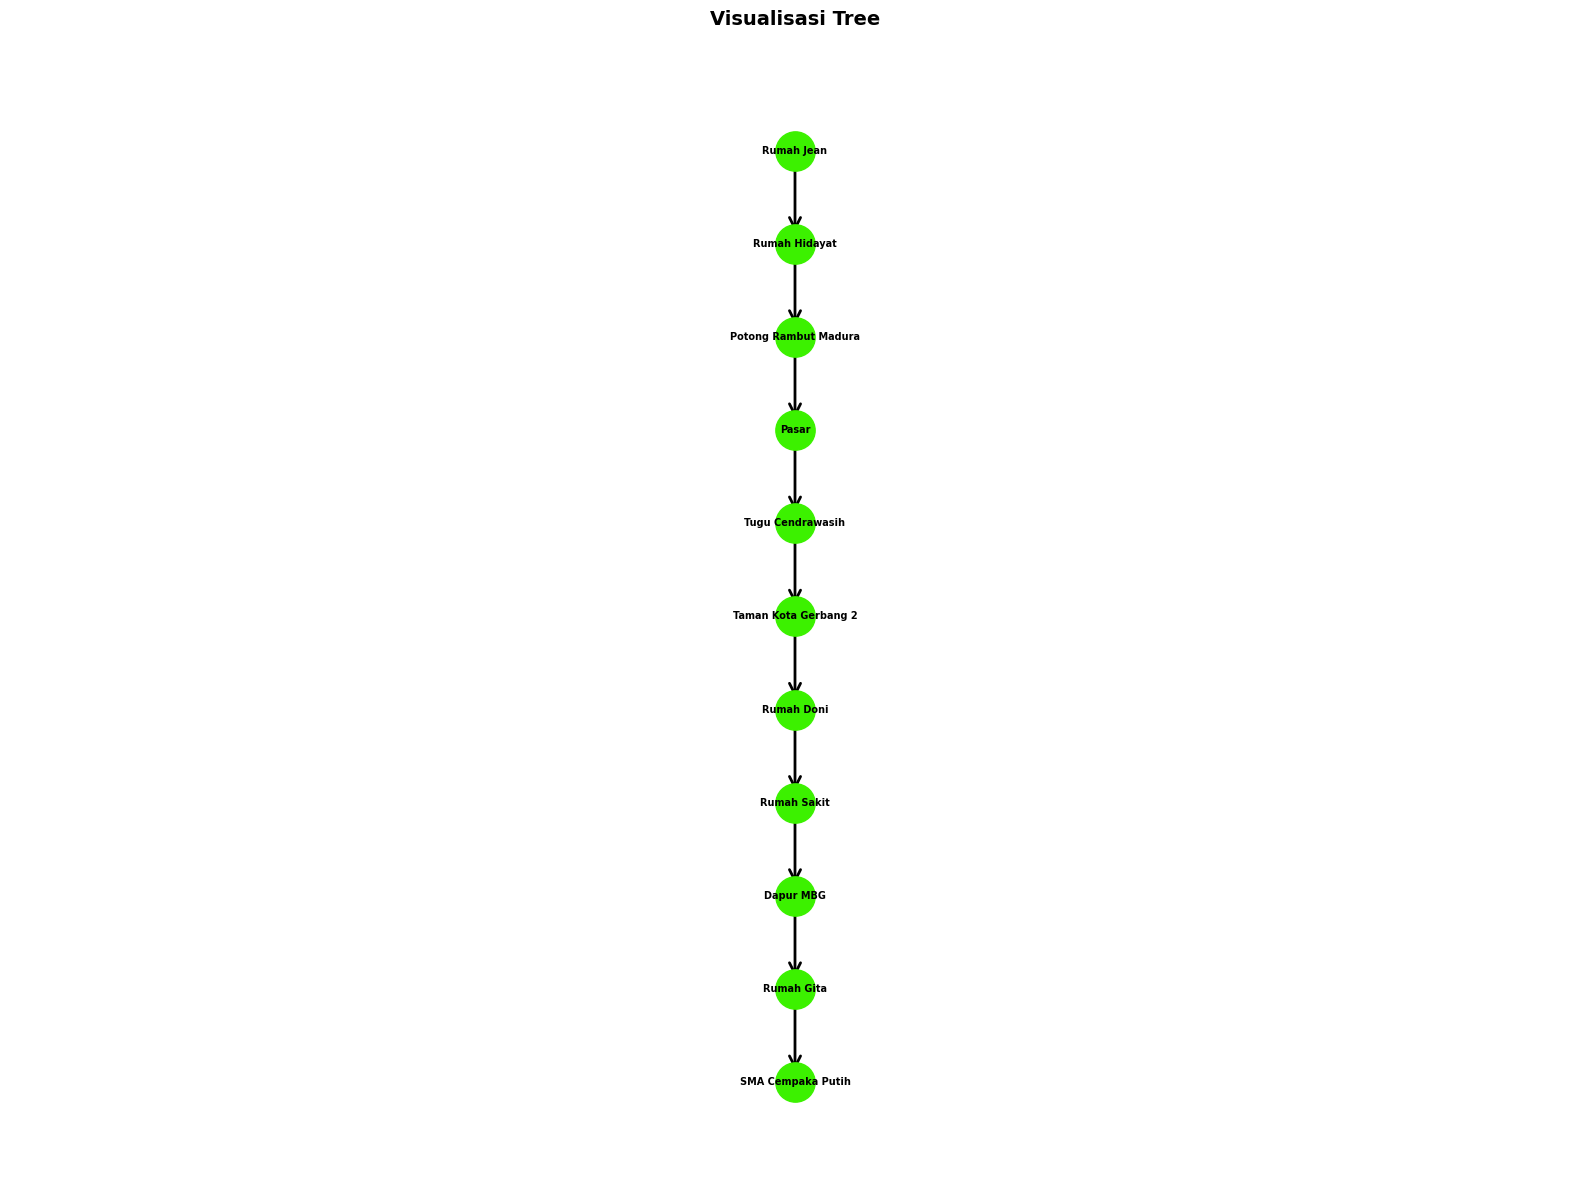

In [71]:
visualisasi_tree(konstruksi_tree_hasil(hasil))

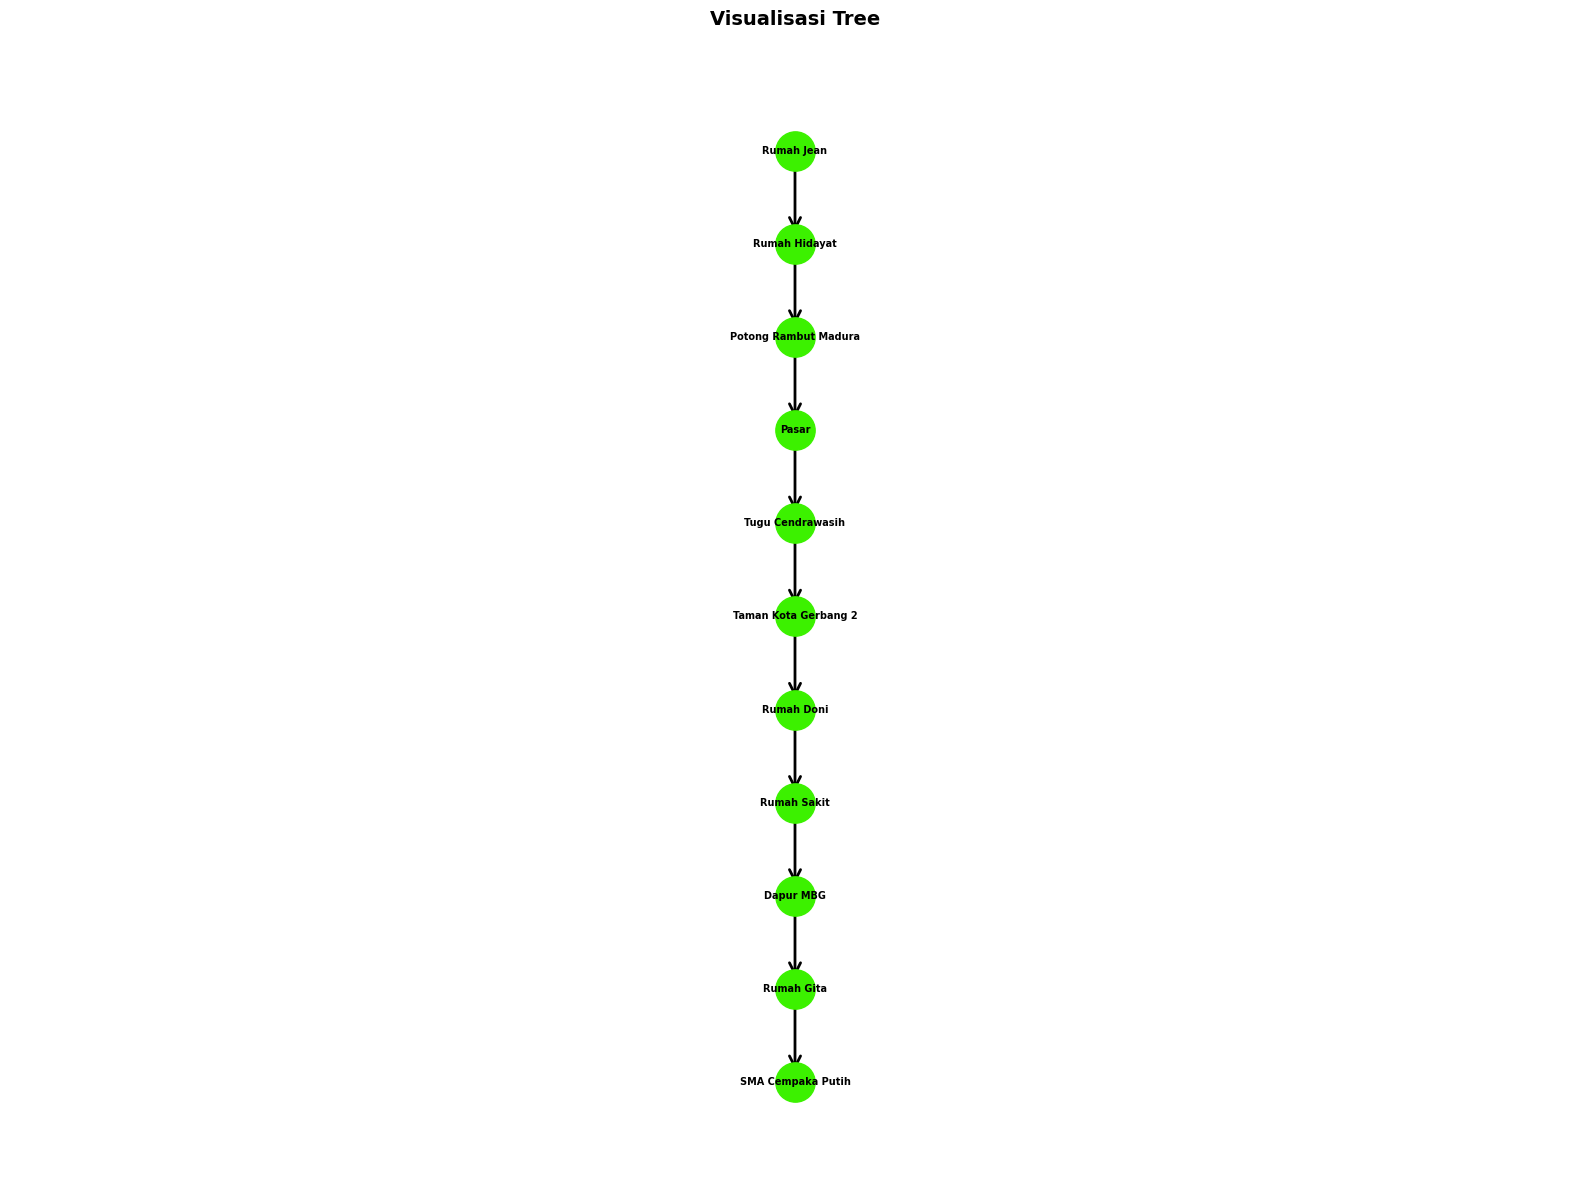

Jarak = 247.52 M


In [72]:
jalan_terpendek = konstruksi_jalan_terpendek(hasil,start,goal,adjlist)
visualisasi_tree(jalan_terpendek["map"])
print(f"Jarak = {jalan_terpendek["jarak"]:.2f} M")

## BFS (Breath First Search)

### Code

In [ ]:
def bfs_searching(adjlist,start,goal) :
    hasil = {}                      # Menyiapkan Tempat Pencatatan Jejak Tempuh
    queue = []                      # Menyiapkan Tempat untuk Antrian Lokasi (FIFO)
    tempat_sekarang = start         # Inisiasi Tempat Awal
    for i in adjlist[tempat_sekarang] :      # Memasukan Semua Lokasi Tetangga awal Ke Queue Sembari Meninggalkan Jejak Tempuh di setiap Tetangga
        hasil[i] = tempat_sekarang
        queue.append(adjlist[tempat_sekarang][i])
    while queue :
        jalan_yang_dipilih = queue.pop(0)    # Memilih Jalan yang akan dilewati berdasarkan aturan FIFO
        tempat_sekarang = jalan_yang_dipilih.menuju.nama       # Berpindah Tempat Sesuai Jalan yang Dipilih
        for i in adjlist[tempat_sekarang] :  # Memasukan Semua Lokasi Tetangga Ke Queue Sembari Meninggalkan Jejak Tempuh di setiap Tetangga
            if i in hasil or i == start :    # Jika Node tetangga sudah pernah dilewati, maka di skip
                continue
            hasil[i] = tempat_sekarang       # Mencatat Jejak Tempuh
            if i == goal :
                return hasil                 # Jika Tetangga yang ditempati adalah Lokasi Tujuan, Maka Fungsi langsung Mengembalikan Jejak Tempuh Berstruktur Child -> Parent
            queue.append(adjlist[tempat_sekarang][i])   # Memasukan Lokasi Tetangga yang ditempati ke Queue
    return hasil

start = "Rumah Jean"
goal = "SMA Cempaka Putih"
hasil = bfs_searching(adjlist,start,goal)

### Visualisasi

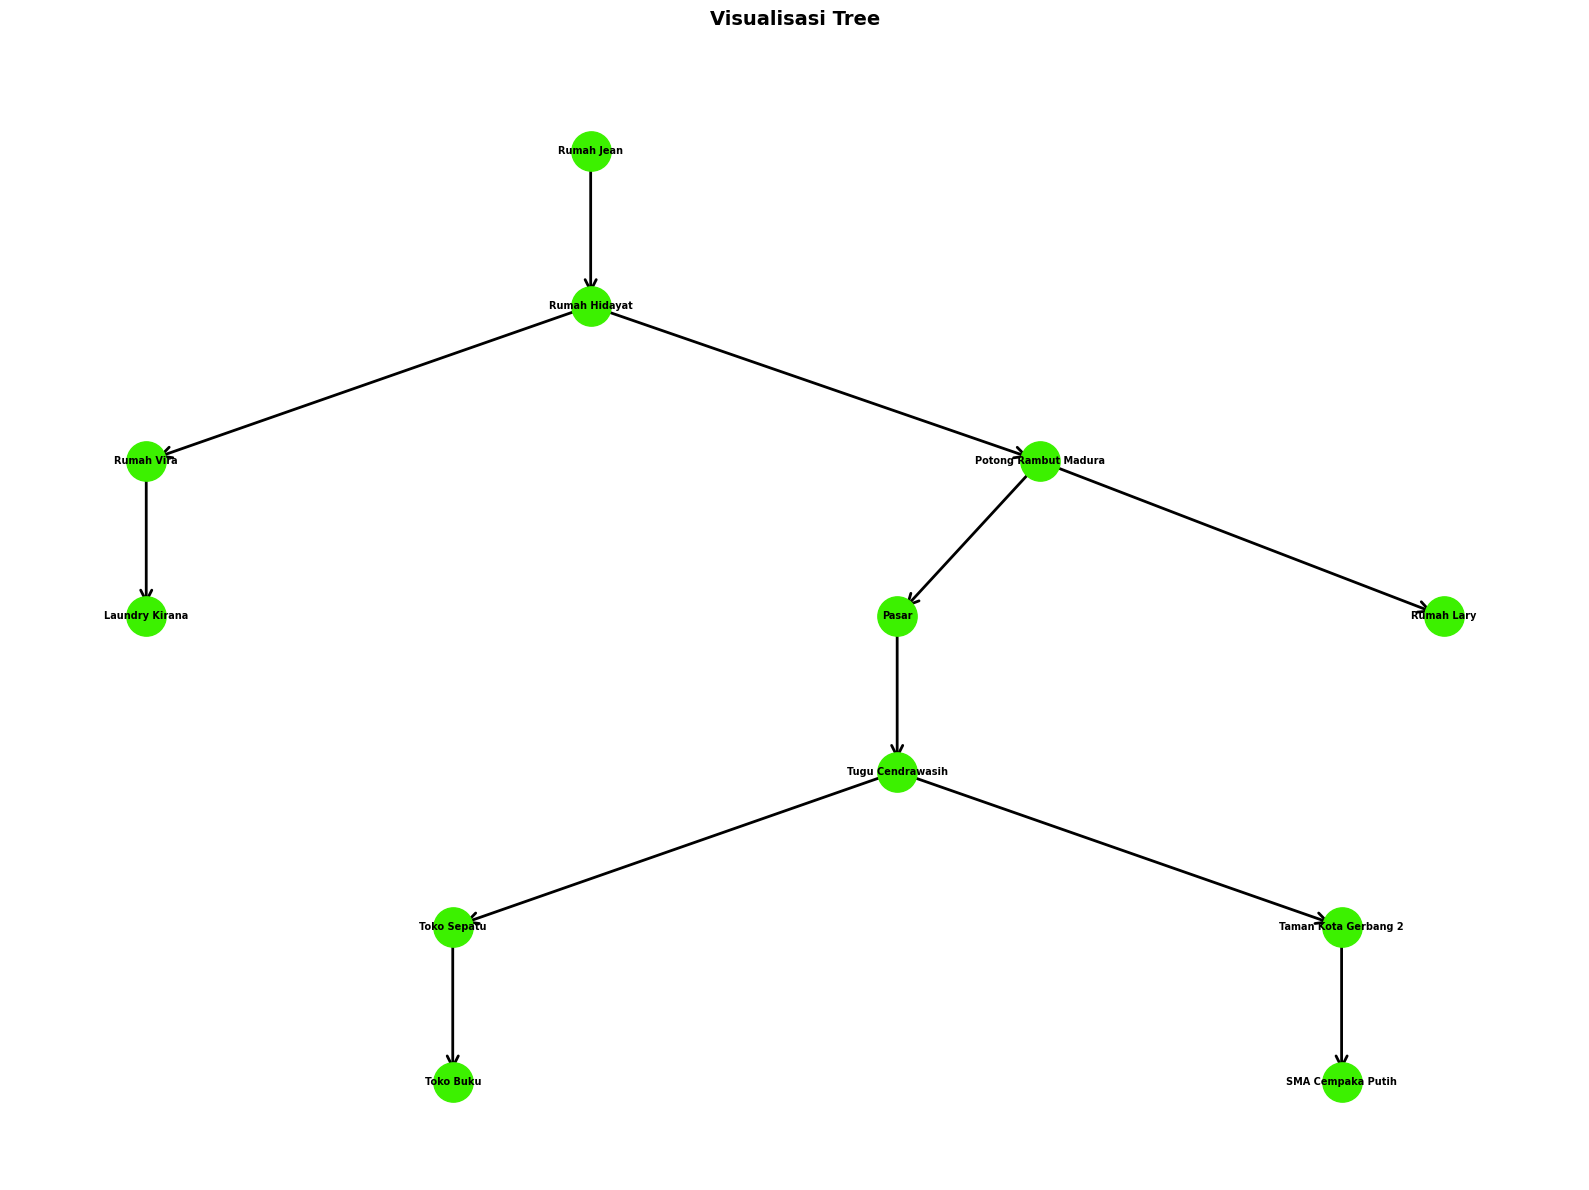

In [74]:
visualisasi_tree(konstruksi_tree_hasil(hasil))

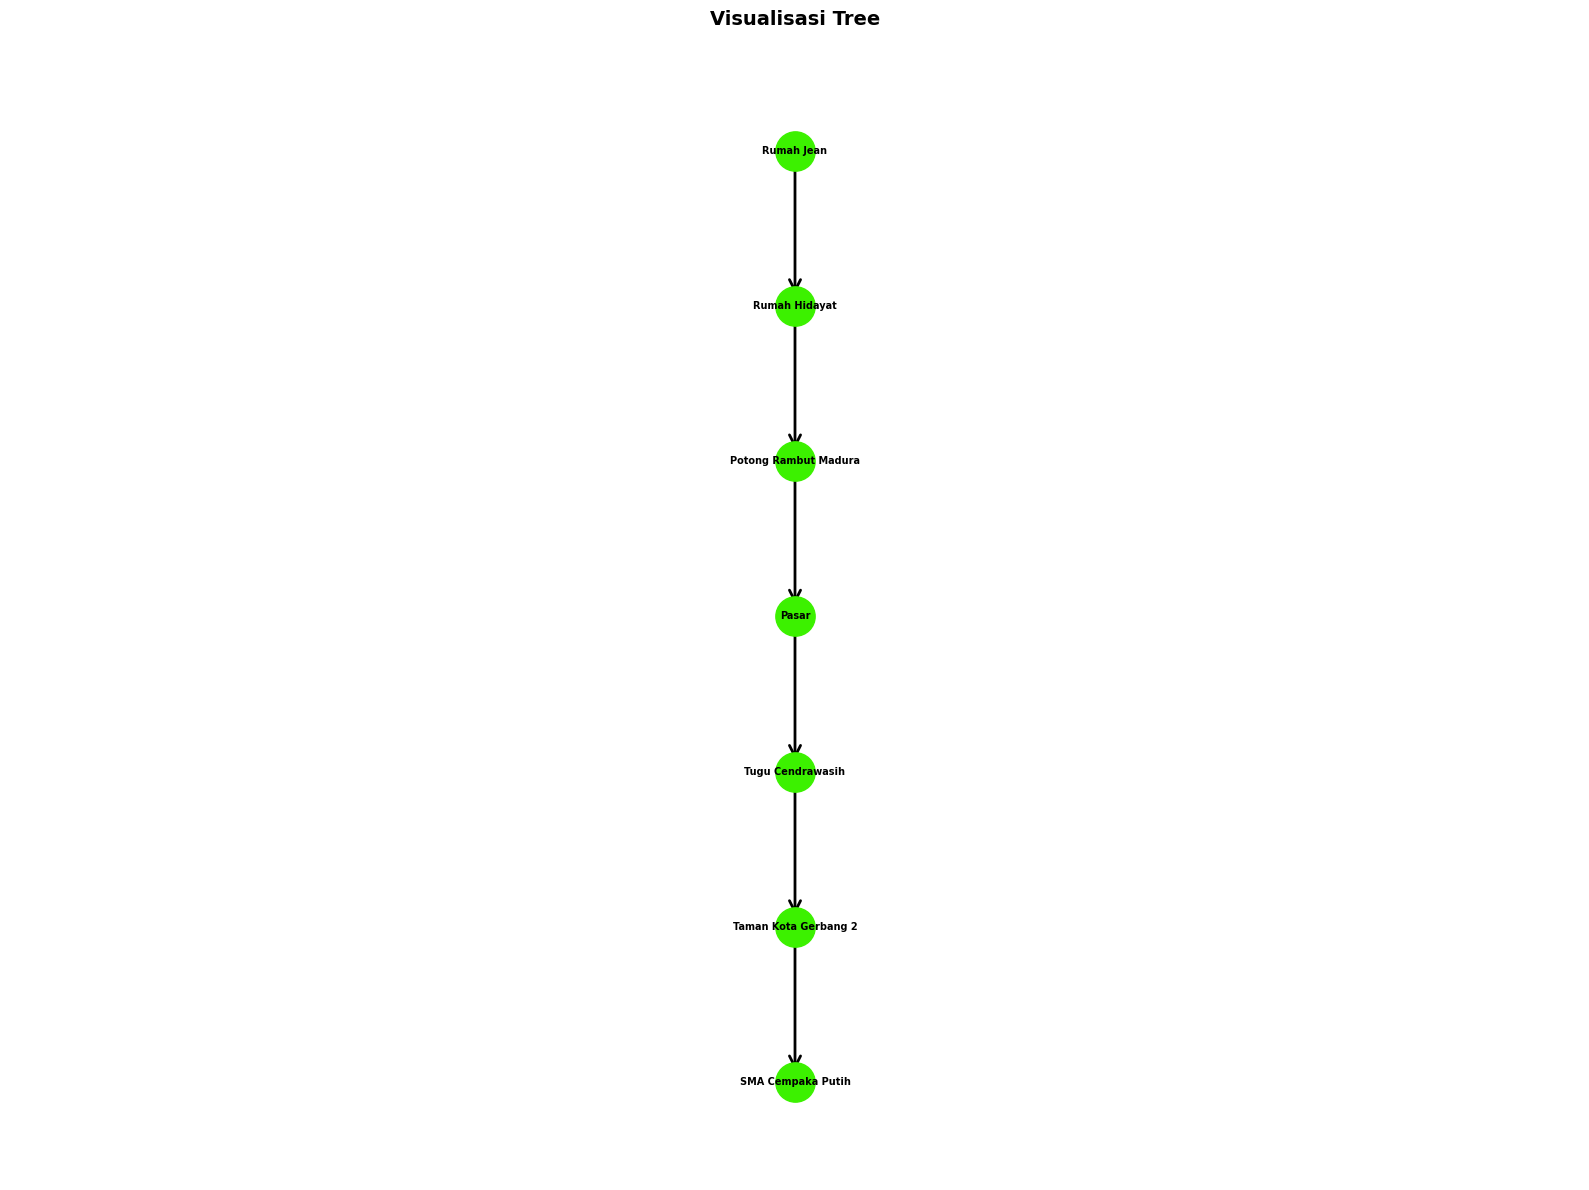

Jarak = 157.96 M


In [75]:
jalan_terpendek = konstruksi_jalan_terpendek(hasil,start,goal,adjlist)
visualisasi_tree(jalan_terpendek["map"])
print(f"Jarak = {jalan_terpendek["jarak"]:.2f} M")

## Greedy Best (Berdasarkan Jarak Koordinat)

### Code

In [ ]:
import heapq as hq

def greedy_best_searching(adjlist,start,goal) :
    hasil = {}                  # Menyiapkan Tempat Pencatatan Jejak Tempuh
    queue = []                  # Menyiapkan Tempat untuk Antrian Lokasi (Priority Queue)
    counter = 1                 # Iterator untuk Error handling jika Jarak Sama
    tempat_sekarang = start     # Inisiasi Tempat Awal
    for i in adjlist[goal] :    # Ini Cuma buat Ambil Objek Tujuannya aja Kok untuk Penghitungan Jarak Koordinat
        lokasi_tujuan = adjlist[goal][i].dari
        break
    for i in adjlist[tempat_sekarang] :     # Memasukan Semua Lokasi Tetangga ke Priority Queue dengan Prioritas Jarak Koordinat Terdekat dengan Goal
        lokasi_yang_dihitung = adjlist[tempat_sekarang][i].menuju
        hasil_penghitungan = (hitung_jarak(lokasi_yang_dihitung,lokasi_tujuan),counter,adjlist[tempat_sekarang][i])
        hq.heappush(queue,hasil_penghitungan)
        counter += 1
    while queue :
        jalan_yang_dipilih = hq.heappop(queue)[2]       # Mengambil Jalan dengan Lokasi yang Paling Dekat dengan Lokasi Tujuan dari Priority Queue
        hasil[jalan_yang_dipilih.menuju.nama] = jalan_yang_dipilih.dari.nama       # Mencatat Jejak Tempuh
        tempat_sekarang = jalan_yang_dipilih.menuju.nama    # Berpindah Tempat Menuju Lokasi berdasarkan jalan yang dipilih
        if tempat_sekarang == goal :            # Jika Lokasi Saat ini adalah Lokasi Tujuan, maka Fungsi langsung mengembalikan Jejak Tempuh Berstruktur Child -> Parent
            return hasil
        for i in adjlist[tempat_sekarang] :     # Memasukan Semua Lokasi Tetangga ke Priority Queue dengan Prioritas Jarak Koordinat Terdekat dengan Goal, Mengecualikan Lokasi yang pernah Ditempuh
            if i in hasil or i == start :
                continue
            lokasi_yang_dihitung = adjlist[tempat_sekarang][i].menuju
            hasil_penghitungan = (hitung_jarak(lokasi_yang_dihitung,lokasi_tujuan),counter,adjlist[tempat_sekarang][i])
            hq.heappush(queue,hasil_penghitungan)
            counter += 1
    return hasil

start = "Rumah Jean"
goal = "SMA Cempaka Putih"
hasil = greedy_best_searching(adjlist,start,goal)

### Visualisasi

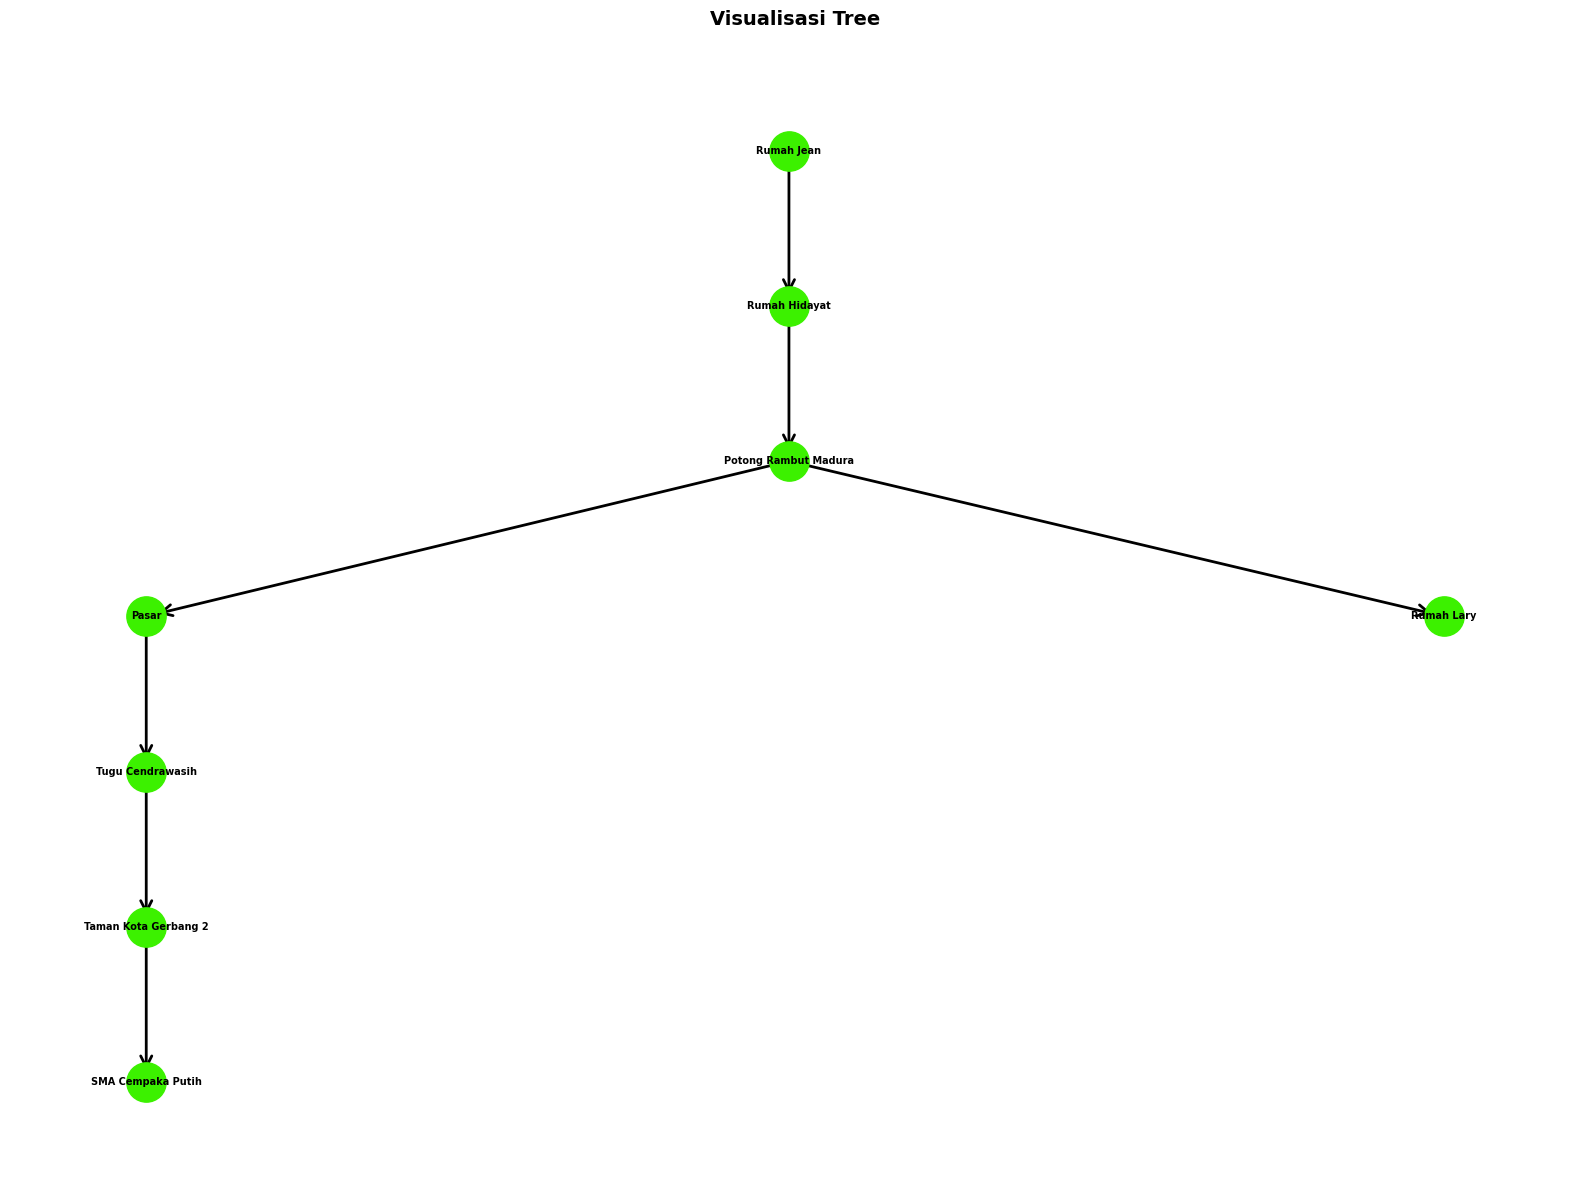

In [77]:
visualisasi_tree(konstruksi_tree_hasil(hasil))

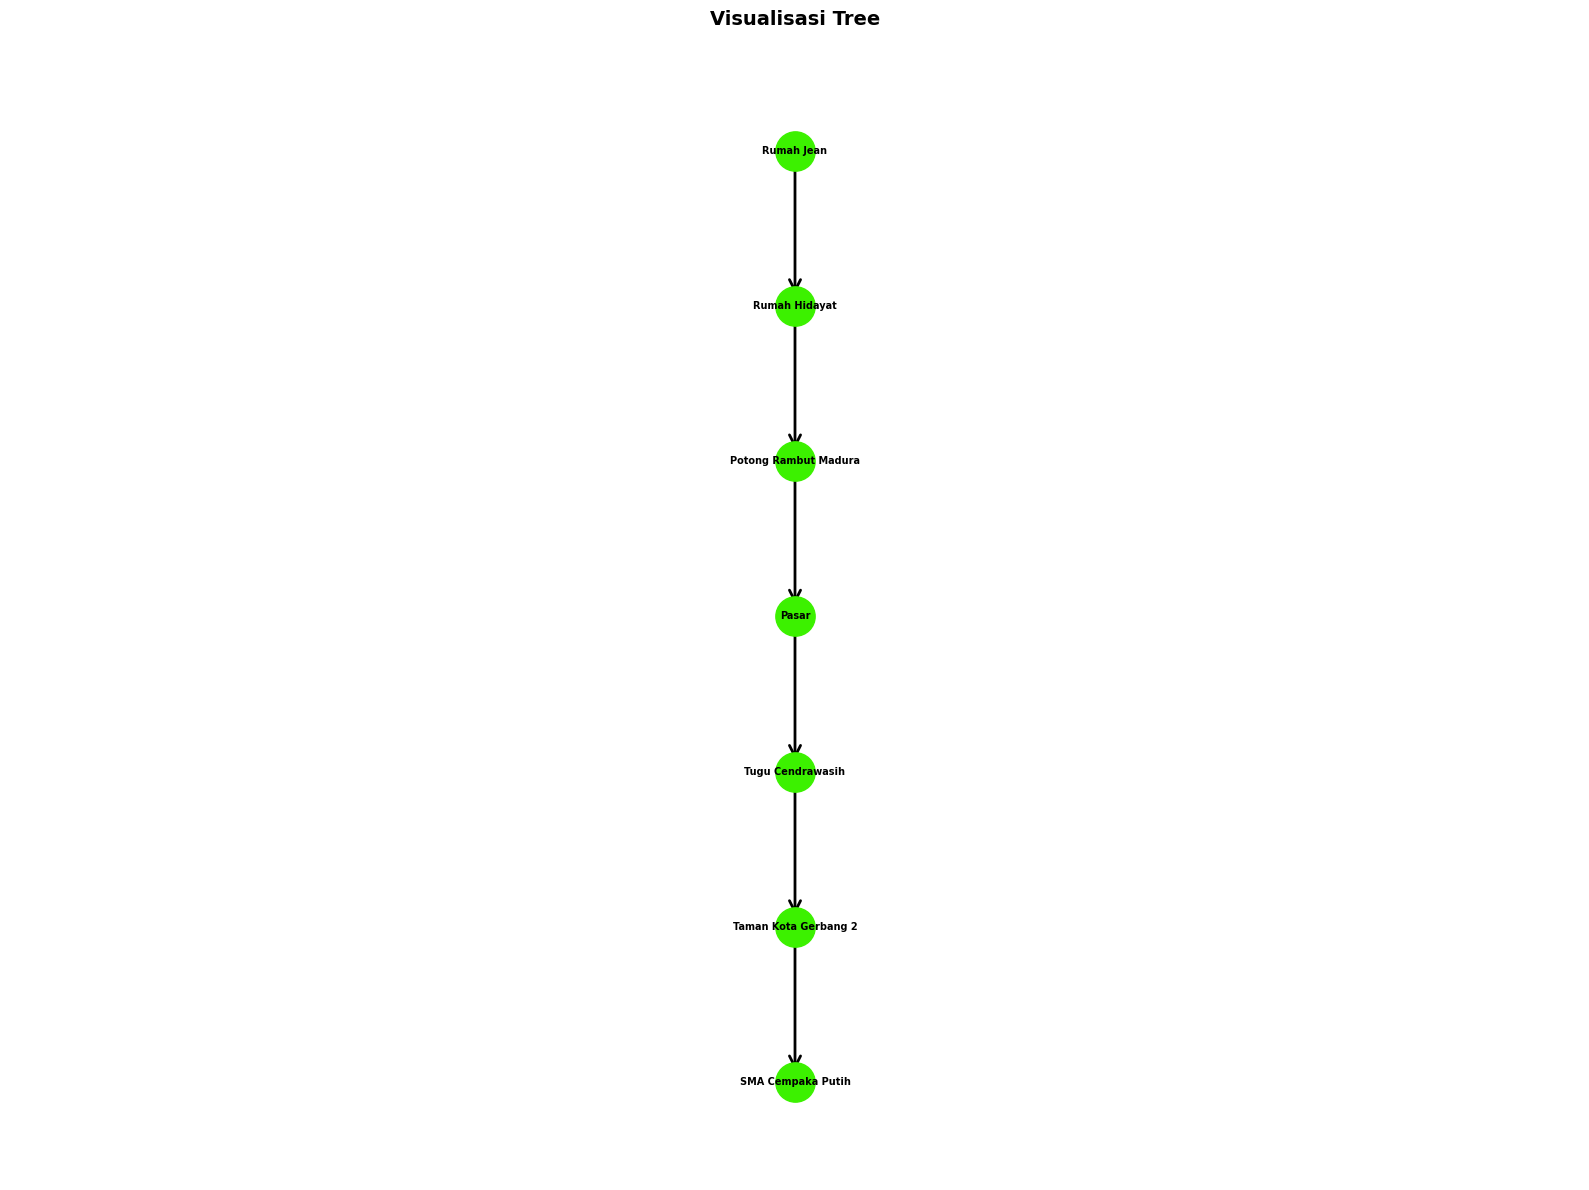

Jarak = 157.96 M


In [78]:
jalan_terpendek = konstruksi_jalan_terpendek(hasil,start,goal,adjlist)
visualisasi_tree(jalan_terpendek["map"])
print(f"Jarak = {jalan_terpendek["jarak"]:.2f} M")

## Djikstra

### Code

In [ ]:
def djikstra_searching(adjlist,start,goal) :
    hasil = {}                  # Menyiapkan Tempat Pencatatan Jejak Tempuh
    queue = []                  # Menyiapkan Tempat untuk Antrian Lokasi (Priority Queue)
    tempat_sekarang = start     # Inisiasi Tempat Awal
    counter = 1                 # Iterator untuk Error handling jika Jarak Sama
    for i in adjlist[start] :   # Memasukan Semua Lokasi Node Tetangga Ke dalam Priority Queue dengan Prioritas Jarak Tempuh dari Lokasi Awal
        jalan_yang_dihitung = adjlist[start][i]
        hq.heappush(queue,(jalan_yang_dihitung.jarak,counter,jalan_yang_dihitung))
        counter += 1
    while queue :
        jarak,_,jalan_yang_dipilih = hq.heappop(queue)                                          # Mengambil Jalan dengan Jarak Tempuh Paling Kecil
        if jalan_yang_dipilih.menuju.nama in hasil or jalan_yang_dipilih.menuju.nama == start : # Jika Lokasi Sudah Dilalui Sebelumnya, Langsung Di skip
            continue
        tempat_sekarang = jalan_yang_dipilih.menuju.nama                # Berpindah Lokasi Sesuai Jalan yang Dipilih
        hasil[tempat_sekarang] = jalan_yang_dipilih.dari.nama           # Mencatat Jejak Tempuh
        if tempat_sekarang == goal :                                    # Jika Lokasi Saat Ini adalah Lokasi Tujuan, maka Fungsi langsung mengembalikan Jejak Tempuh Berstruktur Child -> Parent
            return hasil
        for i in adjlist[tempat_sekarang] :                             # Memasukan Semua Lokasi Node Tetangga Ke dalam Priority Queue dengan Prioritas Jarak Tempuh dari Lokasi Awal
            if i == start or i in hasil :                               # Mengecualikan Lokasi yang Pernah Dikunjungi
                continue
            jalan_yang_dihitung = adjlist[tempat_sekarang][i]
            hq.heappush(queue,(jalan_yang_dihitung.jarak + jarak,counter,jalan_yang_dihitung))
            counter +=1
    return hasil

start = "Rumah Jean"
goal = "SMA Cempaka Putih"
hasil = djikstra_searching(adjlist,start,goal)

### Visualisasi

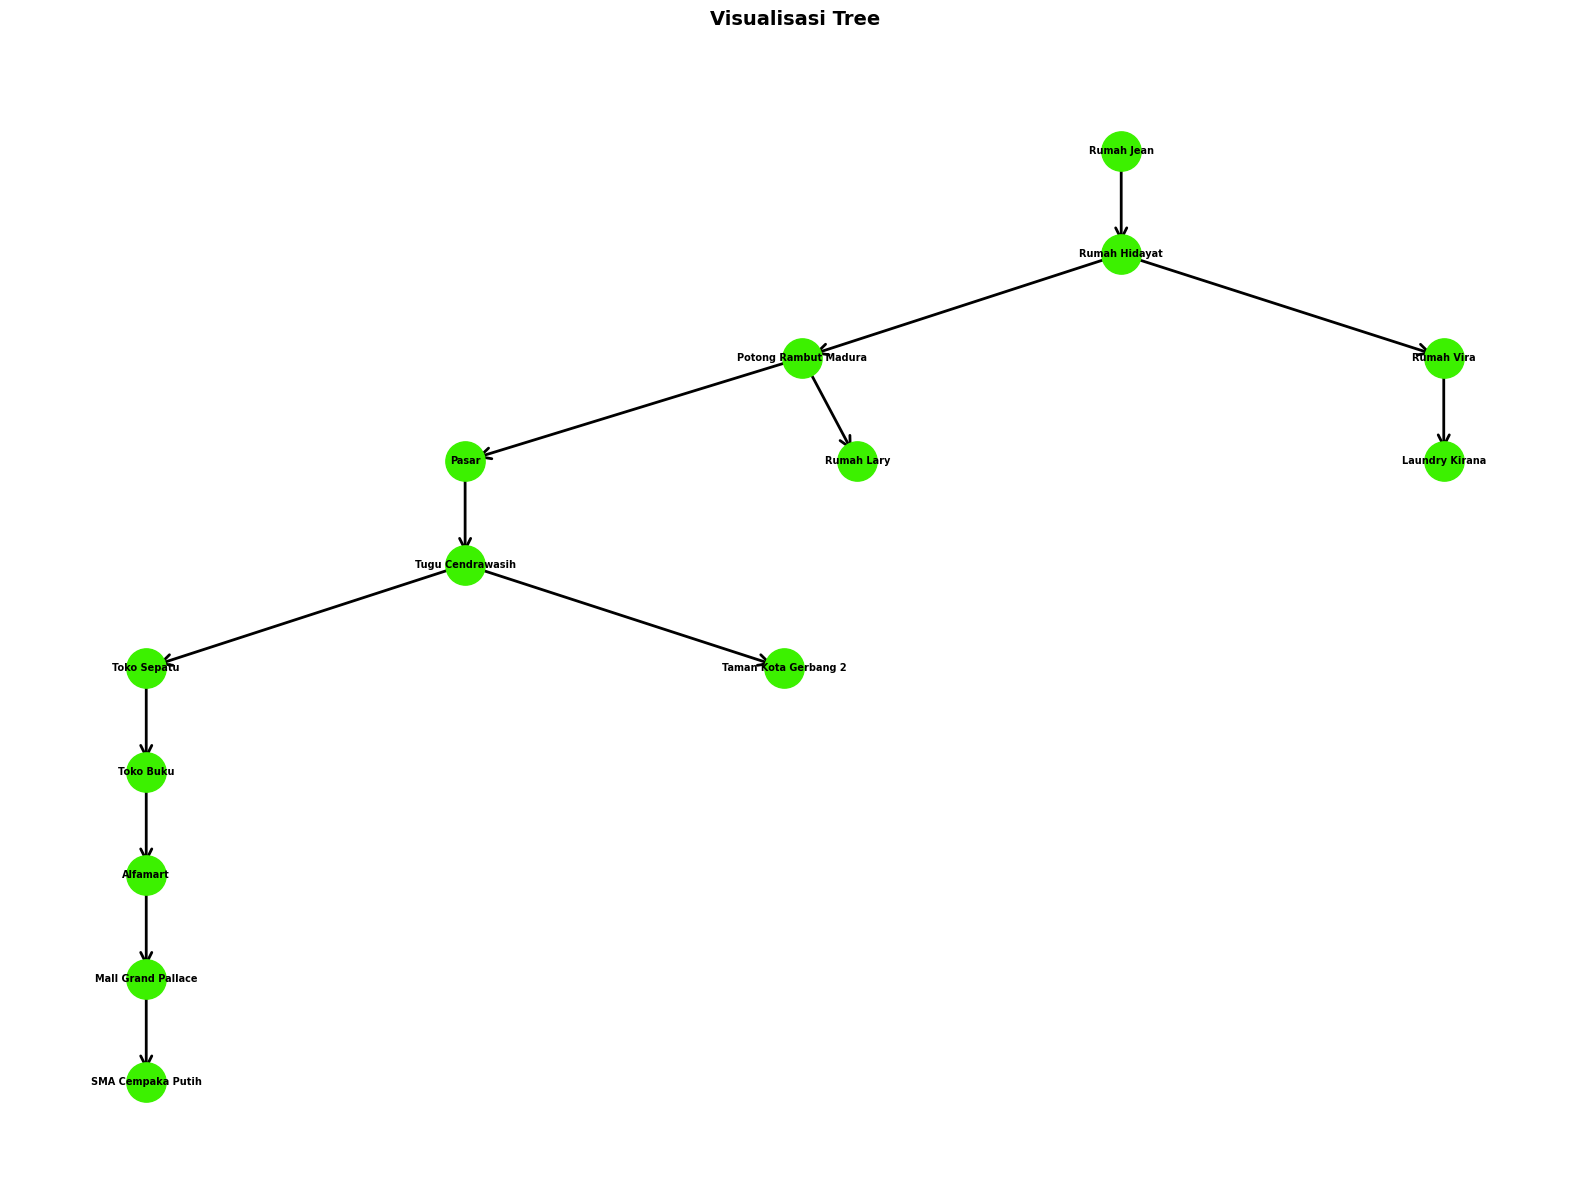

In [80]:
visualisasi_tree(konstruksi_tree_hasil(hasil))

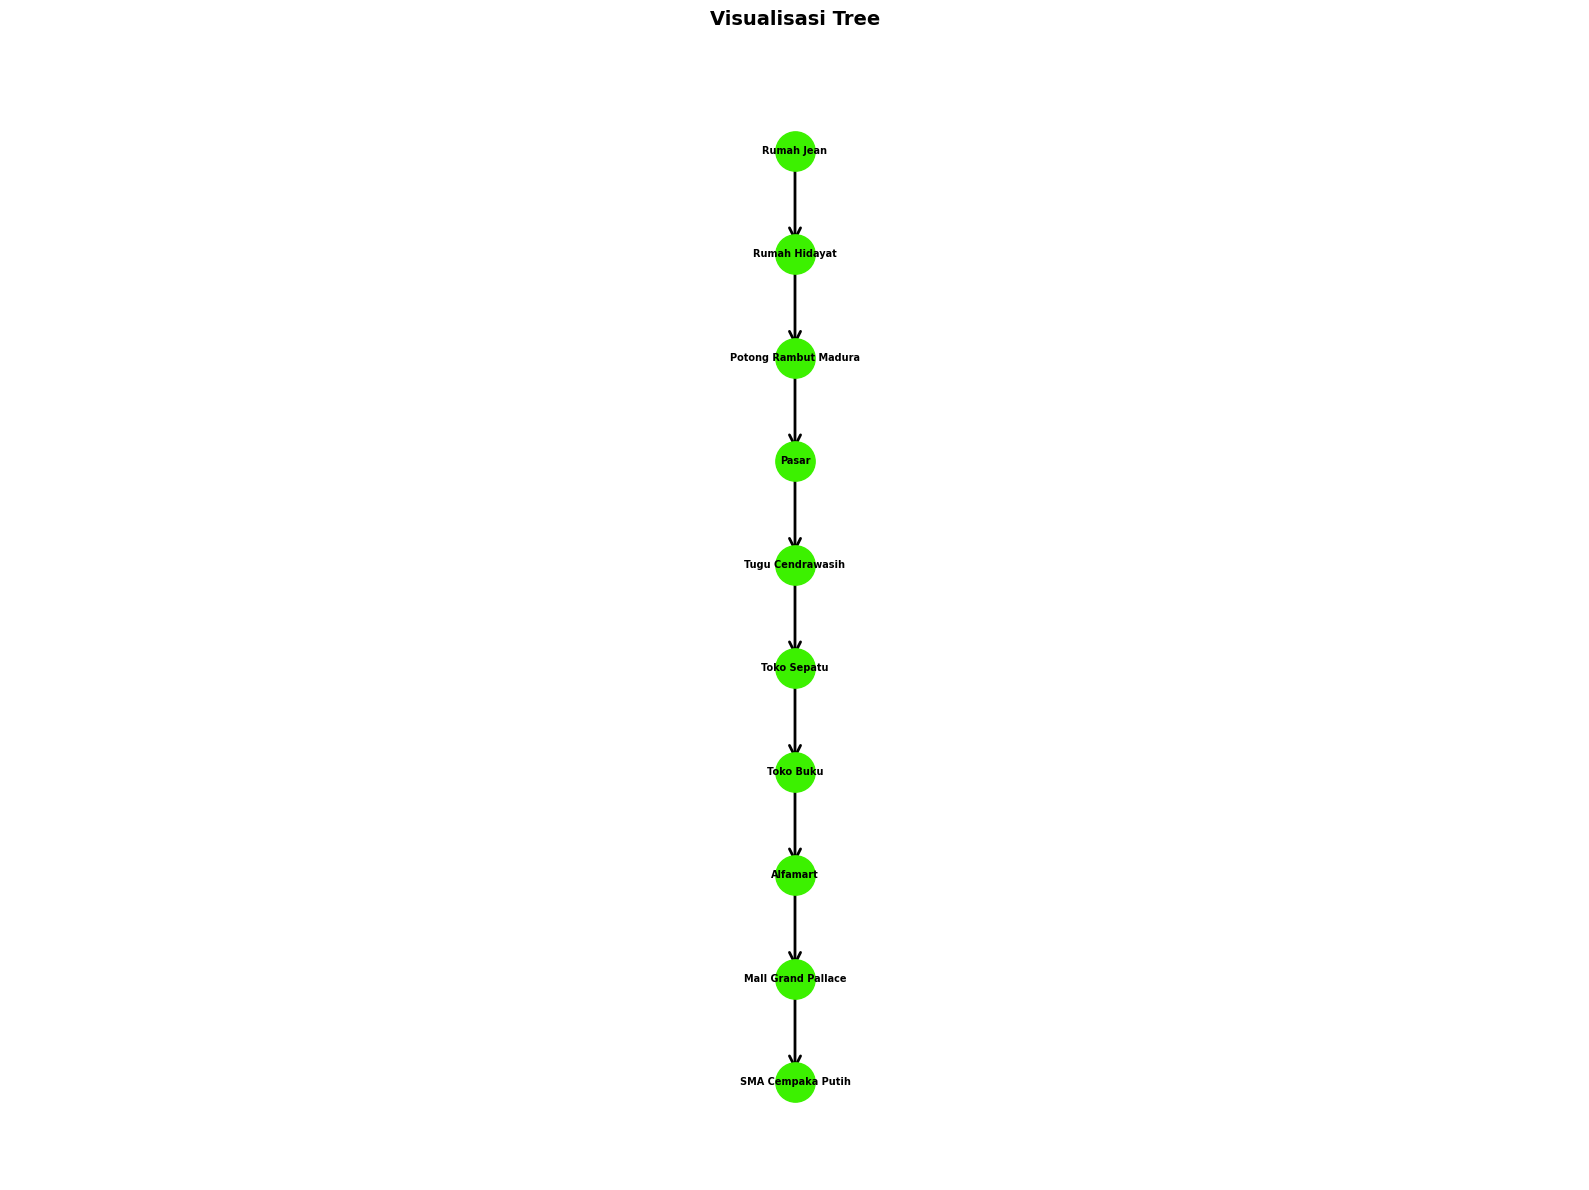

Jarak = 130.81 M


In [81]:
jalan_terpendek = konstruksi_jalan_terpendek(hasil,start,goal,adjlist)
visualisasi_tree(jalan_terpendek["map"])
print(f"Jarak = {jalan_terpendek["jarak"]:.2f} M")

## A* (Jarak Tempuh, Jarak Koordinat)

### Code

In [ ]:
def a_star_searching (adjlist,start,goal) :
    hasil = {}                  # Menyiapkan Tempat Pencatatan Jejak Tempuh
    queue = []                  # Menyiapkan Tempat untuk Antrian Lokasi (Priority Queue)
    tempat_sekarang = start     # Inisiasi Tempat Awal
    counter = 1                 # Iterator untuk Error handling jika Jarak Sama
    for i in adjlist[goal] :    # Ini Cuma buat Ambil Objek Tujuannya aja Kok untuk Penghitungan Jarak Koordinat                                                        # f(n) = g(n) + h(n)
        lokasi_tujuan = adjlist[goal][i].dari                                                                                                                           # g(n) = Jarak Tempuh
        break                                                                                                                                                           # h(n) = Jarak Koordinat
    for i in adjlist[start] :   # Memasukan Semua Lokasi Node Tetangga Ke dalam Priority Queue dengan Prioritas (Jarak Tempuh dari Lokasi Awal + Jarak Koordinat)
        jalan_yang_dihitung = adjlist[start][i]
        hq.heappush(queue,(jalan_yang_dihitung.jarak + hitung_jarak(jalan_yang_dihitung.menuju,lokasi_tujuan),counter,jalan_yang_dihitung.jarak,jalan_yang_dihitung))
        counter += 1
    while queue :
        _,_,jarak,jalan_yang_dipilih = hq.heappop(queue)                                        # Mengambil Jalan dengan (Jarak Tempuh + Jarak Koordinat) Paling Kecil
        if jalan_yang_dipilih.menuju.nama in hasil or jalan_yang_dipilih.menuju.nama == start : # Jika Lokasi Sudah Dilalui Sebelumnya, Langsung Di skip
            continue
        tempat_sekarang = jalan_yang_dipilih.menuju.nama            # Berpindah Lokasi Sesuai Jalan Yang Dipilih
        hasil[tempat_sekarang] = jalan_yang_dipilih.dari.nama       # Mencatat Jejak Tempuh
        if tempat_sekarang == goal :                                # Jika Lokasi Saat Ini adalah Lokasi Tujuan, maka Fungsi langsung mengembalikan Jejak Tempuh Berstruktur Child -> Parent
            return hasil
        for i in adjlist[tempat_sekarang] :                         # Memasukan Semua Lokasi Node Tetangga Ke dalam Priority Queue dengan Prioritas (Jarak Tempuh dari Lokasi Awal + Jarak Koordinat)
            if i == start or i in hasil :                           # Mengecualikan Lokasi yang Pernah Dikunjungi
                continue
            jalan_yang_dihitung = adjlist[tempat_sekarang][i]
            hq.heappush(queue,(jalan_yang_dihitung.jarak + jarak + hitung_jarak(jalan_yang_dihitung.menuju,lokasi_tujuan),counter,jalan_yang_dihitung.jarak + jarak,jalan_yang_dihitung))
            counter +=1
    return hasil

start = "Rumah Jean"
goal = "SMA Cempaka Putih"
hasil = a_star_searching(adjlist,start,goal)

### Visualisasi

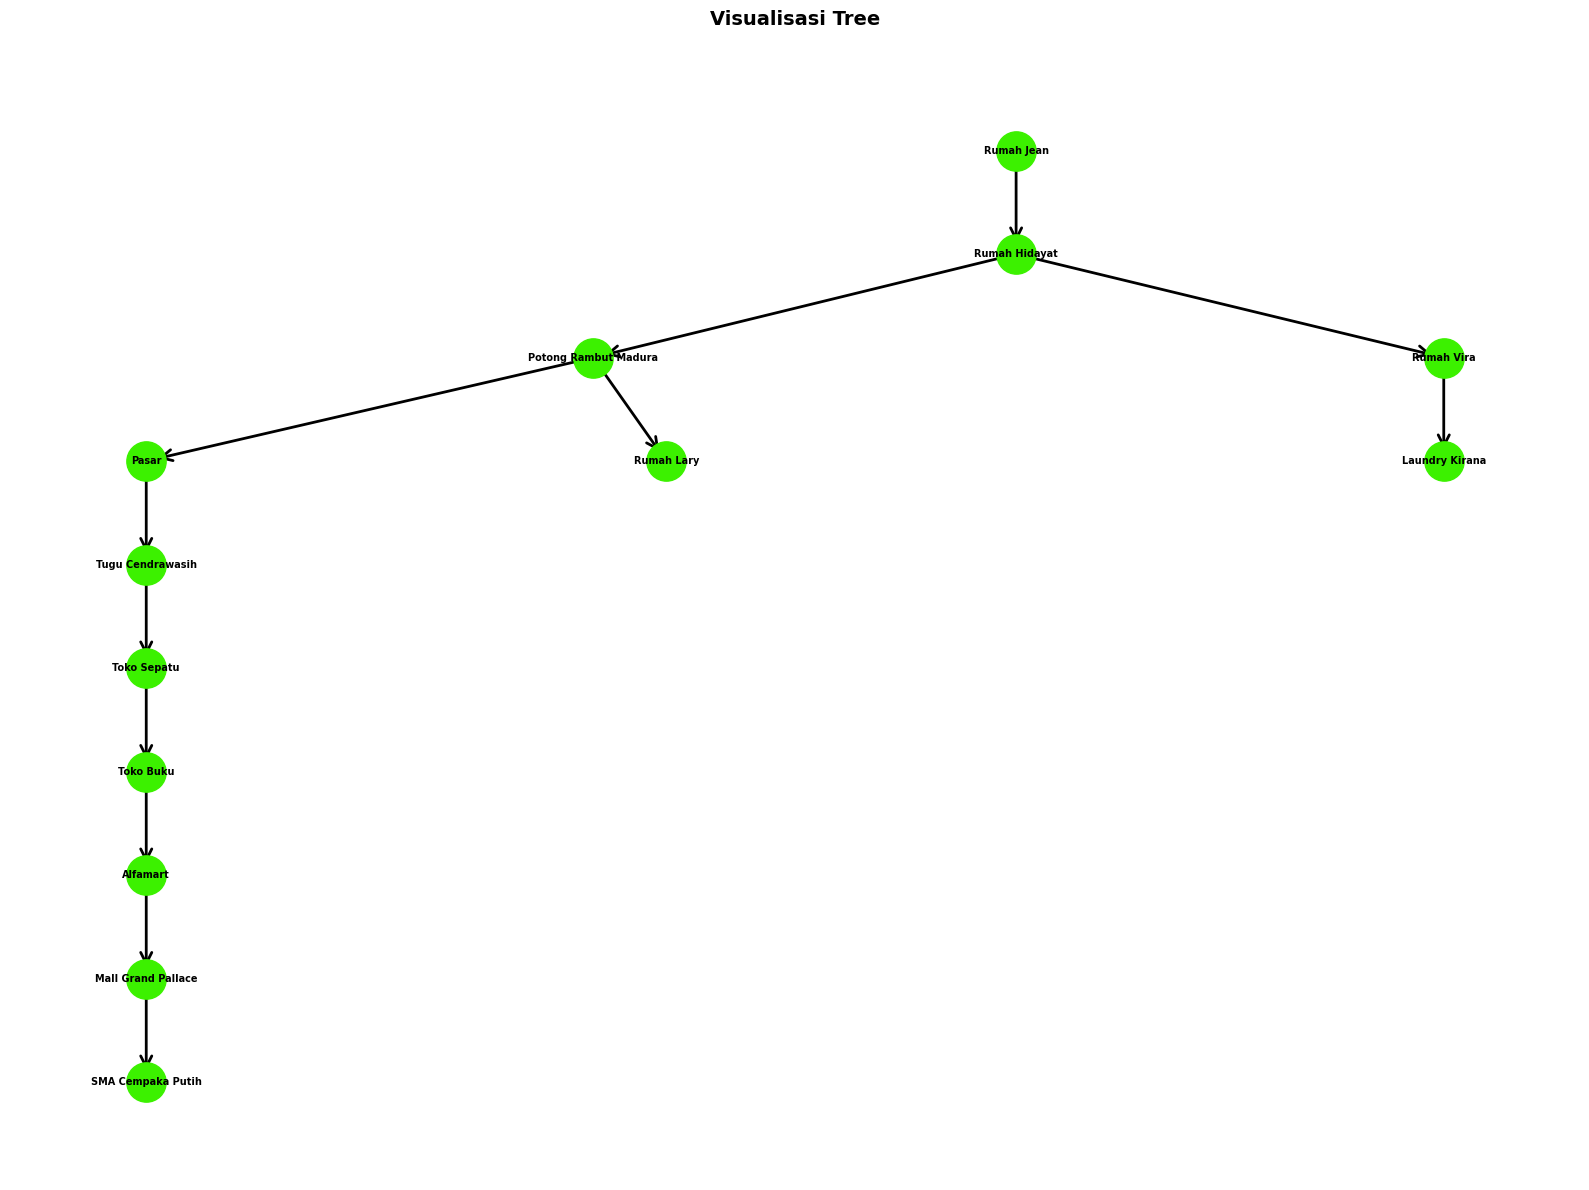

In [83]:
visualisasi_tree(konstruksi_tree_hasil(hasil))

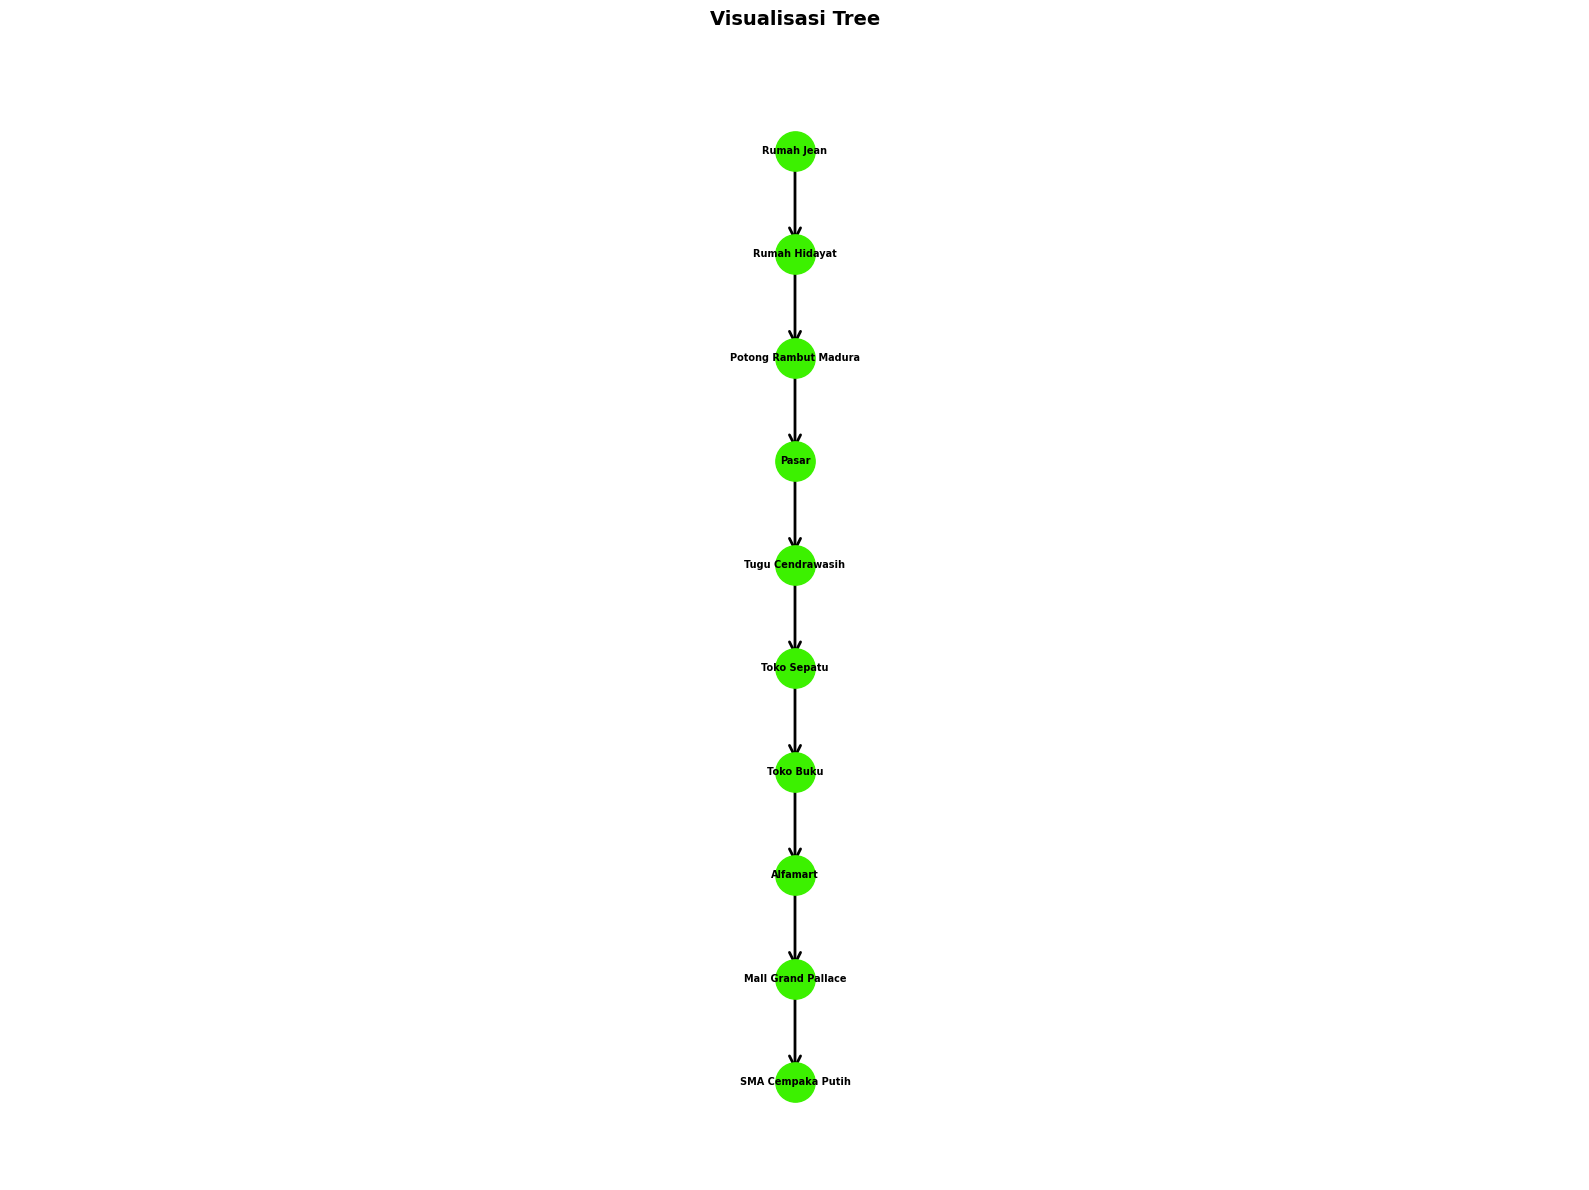

Jarak = 130.81 M


In [84]:
jalan_terpendek = konstruksi_jalan_terpendek(hasil,start,goal,adjlist)
visualisasi_tree(jalan_terpendek["map"])
print(f"Jarak = {jalan_terpendek["jarak"]:.2f} M")